## Домашнее задание #4: исследование линейной регрессии

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('ToyotaCorolla.csv')
print(df.shape)
df.head()
df

(1436, 10)


,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23,46986,Diesel,90,1,0,2000,3,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,1,0,1300,3,1025
1432,10845,72,19000,Petrol,86,0,0,1300,3,1015
1433,8500,71,17016,Petrol,86,0,0,1300,3,1015
1434,7250,70,16916,Petrol,86,1,0,1300,3,1015


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   FuelType   1436 non-null   object
 4   HP         1436 non-null   int64 
 5   MetColor   1436 non-null   int64 
 6   Automatic  1436 non-null   int64 
 7   CC         1436 non-null   int64 
 8   Doors      1436 non-null   int64 
 9   Weight     1436 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 112.3+ KB


In [8]:
df.describe()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.674791,0.055710,1566.827994,4.033426,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.468616,0.229441,187.182436,0.952677,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,0.000000,1300.000000,2.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,0.000000,1400.000000,3.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,1.000000,0.000000,1600.000000,4.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,1.000000,0.000000,1600.000000,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,1.000000,2000.000000,5.000000,1615.00000


In [9]:
df.isnull().sum()

Price        0
Age          0
KM           0
FuelType     0
HP           0
MetColor     0
Automatic    0
CC           0
Doors        0
Weight       0
dtype: int64

Text(0, 0.5, 'frequency')

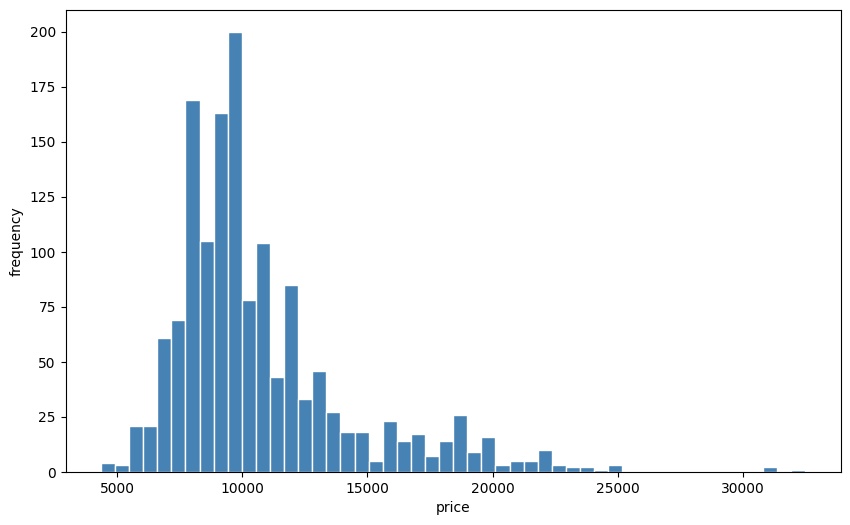

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=50, color= 'steelblue', edgecolor='white')

plt.xlabel('price')
plt.ylabel('frequency')


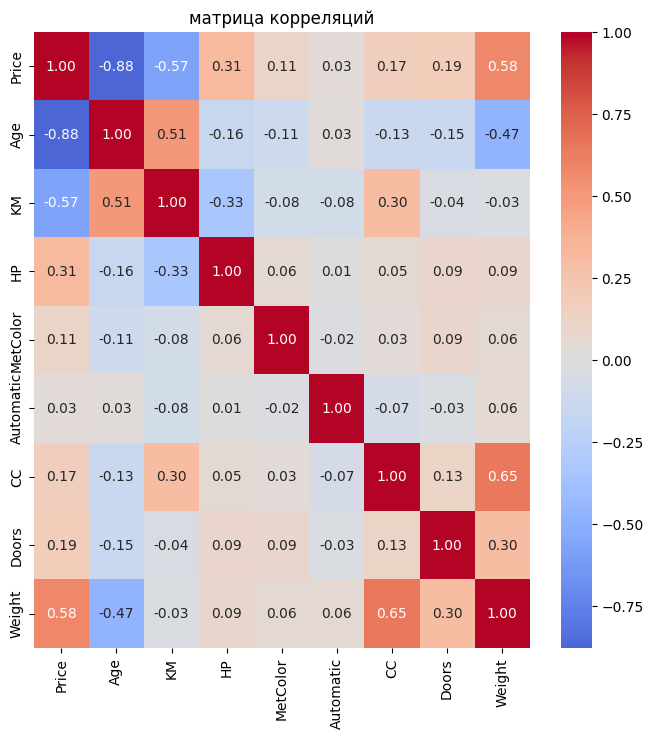

корреляция с price:
Price        1.000000
Weight       0.581198
HP           0.314990
Doors        0.185326
CC           0.165067
MetColor     0.108905
Automatic    0.033081
KM          -0.569960
Age         -0.876590
Name: Price, dtype: float64


In [11]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('матрица корреляций')
plt.show()

print('корреляция с price:')
print(numeric_df.corr()['Price'].sort_values(ascending=False))

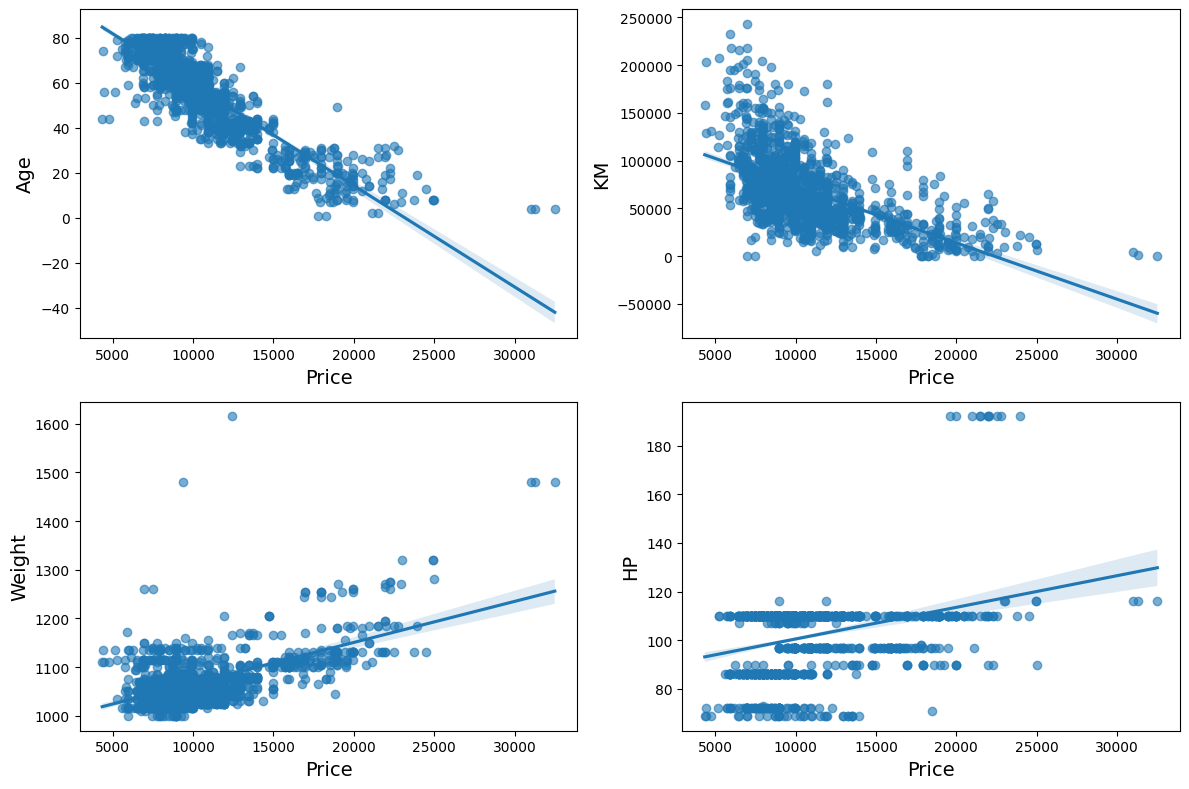

In [12]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='Weight', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('Weight', fontsize=14)

sns.regplot(x='Price', y='HP', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('HP', fontsize=14)

plt.tight_layout()
plt.show()

сильнее всего на цену влияют возраст и пробег - обратная зависимость очень чёткая. 
вес умеренно коррелирует с ценой положительно.
мощность (HP) практически не влияет на цену - точки разбросаны без явного тренда

## Работа с признаками



In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('Price',axis=1).values
y = df_encoded['Price'].values.reshape(-1,1)
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

# признак типа топлива (Fuel_Type) преобразовала с помощью One-Hot Encoding, чтобы линейная регрессия могла с ним работать


Shape of X_train:  (1077, 10)
Shape of X_test:  (359, 10)


In [14]:
print(set(df['FuelType']))
df_encoded.head()

{'Petrol', 'Diesel', 'CNG'}


,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,FuelType_Diesel,FuelType_Petrol
0,13500,23,46986,90,1,0,2000,3,1165,True,False
1,13750,23,72937,90,1,0,2000,3,1165,True,False
2,13950,24,41711,90,1,0,2000,3,1165,True,False
3,14950,26,48000,90,0,0,2000,3,1165,True,False
4,13750,30,38500,90,0,0,2000,3,1170,True,False


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

я использовала One-Hot Encoding для признака типа топлива, чтобы перевести категории в понятные для модели числа. лишние технические признаки в таблице отсутствовали, поэтому удалять колонки не пришлось.

# обучение моделей

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

lasso_params = {'alpha': [0.01, 0.1, 1.0, 5.0]}
lasso_cv = GridSearchCV(Lasso(), lasso_params, cv=5)
lasso_cv.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.01, 0.1, 1.0, 5.0]})

выборка разделена на обучающую и тестовую, чтобы проверить модель на данных, которые она раньше не видела. масштабирование (StandardScaler) применено, чтобы штраф в Ridge/Lasso распределялся равномерно.

In [17]:
def print_metrics(model, name, X_t, y_t):
    pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_t, pred))
    r2 = r2_score(y_t, pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

print("Результаты на тестовой выборке:")
print_metrics(lr, "Linear Regression", X_test_scaled, y_test)
print_metrics(ridge_cv.best_estimator_, f"Ridge (alpha={ridge_cv.best_params_['alpha']})", X_test_scaled, y_test)
print_metrics(lasso_cv.best_estimator_, f"Lasso (alpha={lasso_cv.best_params_['alpha']})", X_test_scaled, y_test)

Результаты на тестовой выборке:
Linear Regression -> RMSE: 1398.46, R2: 0.8622
Ridge (alpha=10.0) -> RMSE: 1406.79, R2: 0.8605
Lasso (alpha=0.01) -> RMSE: 1398.48, R2: 0.8622


RMSE выбрана потому, что она показывает среднюю ошибку предсказания в тех же единицах измерения, что и целевая переменная (то есть в евро/долларах). в отличие от MAE, RMSE сильнее 'штрафует' модель за грубые ошибки.

коэффициент детерминации нужен, чтобы понять общую адекватность модели; он показывает, какую долю дисперсии в ценах на машины модель смогла объяснить.

итоговые метрики рассчитаны строго на тестовой выборке, которую мы отделили в начале и не показывали моделям во время обучения.

лучше всего справились Linear Regression и Lasso (с коэффициентом alpha=0.01). они показали идентичный результат RMSE=1398.48 и R^2=0.8622. Ridge сработала немного хуже (RMSE=1406.79).

результаты можно назвать хорошими. значение R^2=0.86 означает, что наша линейная модель объясняет более 86% факторов, влияющих на цену автомобиля. ошибка RMSE около 1400 единиц, для рынка автомобилей промах в 1400 евро - приемлемый  результат.

об отсутствии переобучения говорят два фактора. во-первых, высокие метрики получены именно на тестовых данных, то есть модель способна хорошо обобщать новые данные, а не заучилаа тренировочный набор. во-вторых, тот факт, что обычная линейная регрессия показала результаты на уровне моделей Lasso и Ridge, доказывает, что проблема огромных весов и переобучения в данном признаковом пространстве отсутствует.